Cargando modelo y datos...


c:\Users\andre\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Simulando predicciones y calculando confianza...
✅ Gráfica profesional guardada como 'histograma_profesional.png'


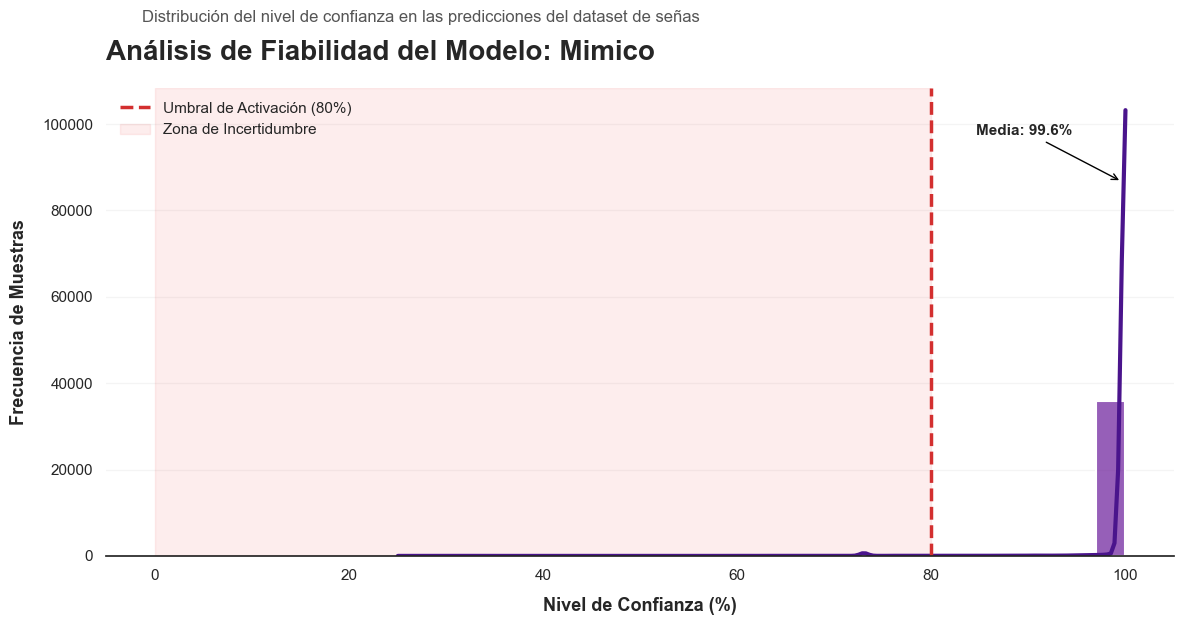

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


# --- Configuración estética global ---
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'


# (Tu lógica de carga de modelo y datos se mantiene igual)
# ... [Código previo de predicción] ...
print("Cargando modelo y datos...")

# 1. Cargar tu modelo TFLite directamente
interpreter = tf.lite.Interpreter(model_path="modelo_teclado.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Cargar tus datos grabados
df = pd.read_csv('datasetLETRAS.csv', on_bad_lines='skip')
X = df.iloc[:, 1:].values.astype(np.float32)

confianzas = []

print("Simulando predicciones y calculando confianza...")
for i in range(len(X)):
    # Preparar la coordenada (una por una)
    input_data = np.expand_dims(X[i], axis=0)
    
    # Hacer la predicción
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    
    # Obtener el porcentaje de seguridad más alto de esa predicción
    confianza_max = np.max(out[0])
    confianzas.append(confianza_max)

# Convertir las confianzas a formato porcentaje (ej. 0.95 -> 95%)
confianzas_pct = [c * 100 for c in confianzas]


# 3. Creación de la Gráfica Profesional
plt.figure(figsize=(12, 7))


# Histograma con estilo mejorado
ax = sns.histplot(
    confianzas_pct,
    bins=25,
    kde=True,
    color='#6a1b9a',  # Un púrpura más profundo y profesional
    edgecolor='white',
    linewidth=1.5,
    alpha=0.7
)


# Personalización de la línea de KDE (Densidad)
ax.lines[0].set_color('#4a148c')
ax.lines[0].set_linewidth(3)


# Línea de umbral más elegante
plt.axvline(x=80, color='#d32f2f', linestyle='--', linewidth=2.5, label='Umbral de Activación (80%)')


# Rellenar el área de "Baja Confianza" para dar contexto visual
plt.axvspan(0, 80, color='#ef5350', alpha=0.1, label='Zona de Incertidumbre')


# Títulos y etiquetas con jerarquía visual
plt.title('Análisis de Fiabilidad del Modelo: Mimico', fontsize=20, pad=20, fontweight='bold', loc='left')
plt.suptitle('Distribución del nivel de confianza en las predicciones del dataset de señas',
             fontsize=12, y=0.92, x=0.125, ha='left', color='#555555')


plt.xlabel('Nivel de Confianza (%)', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Frecuencia de Muestras', fontsize=13, fontweight='bold', labelpad=10)


# Limpiar el marco (despina)
sns.despine(left=True, bottom=False)


# Añadir anotación estadística
media_confianza = np.mean(confianzas_pct)
plt.annotate(f'Media: {media_confianza:.1f}%',
             xy=(media_confianza, ax.get_ylim()[1]*0.8),
             xytext=(media_confianza-15, ax.get_ylim()[1]*0.9),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')


# Mejorar el grid y leyenda
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.legend(frameon=False, loc='upper left', fontsize=11)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])


# Guardar y mostrar
plt.savefig('histograma_profesional.png', dpi=300, bbox_inches='tight')
print("✅ Gráfica profesional guardada como 'histograma_profesional.png'")
plt.show()




🔄 Cargando modelo y datos...
🔄 Generando predicciones...
   Precisión global: 3.0%
✅ Guardada como 'matriz_confusion.png'


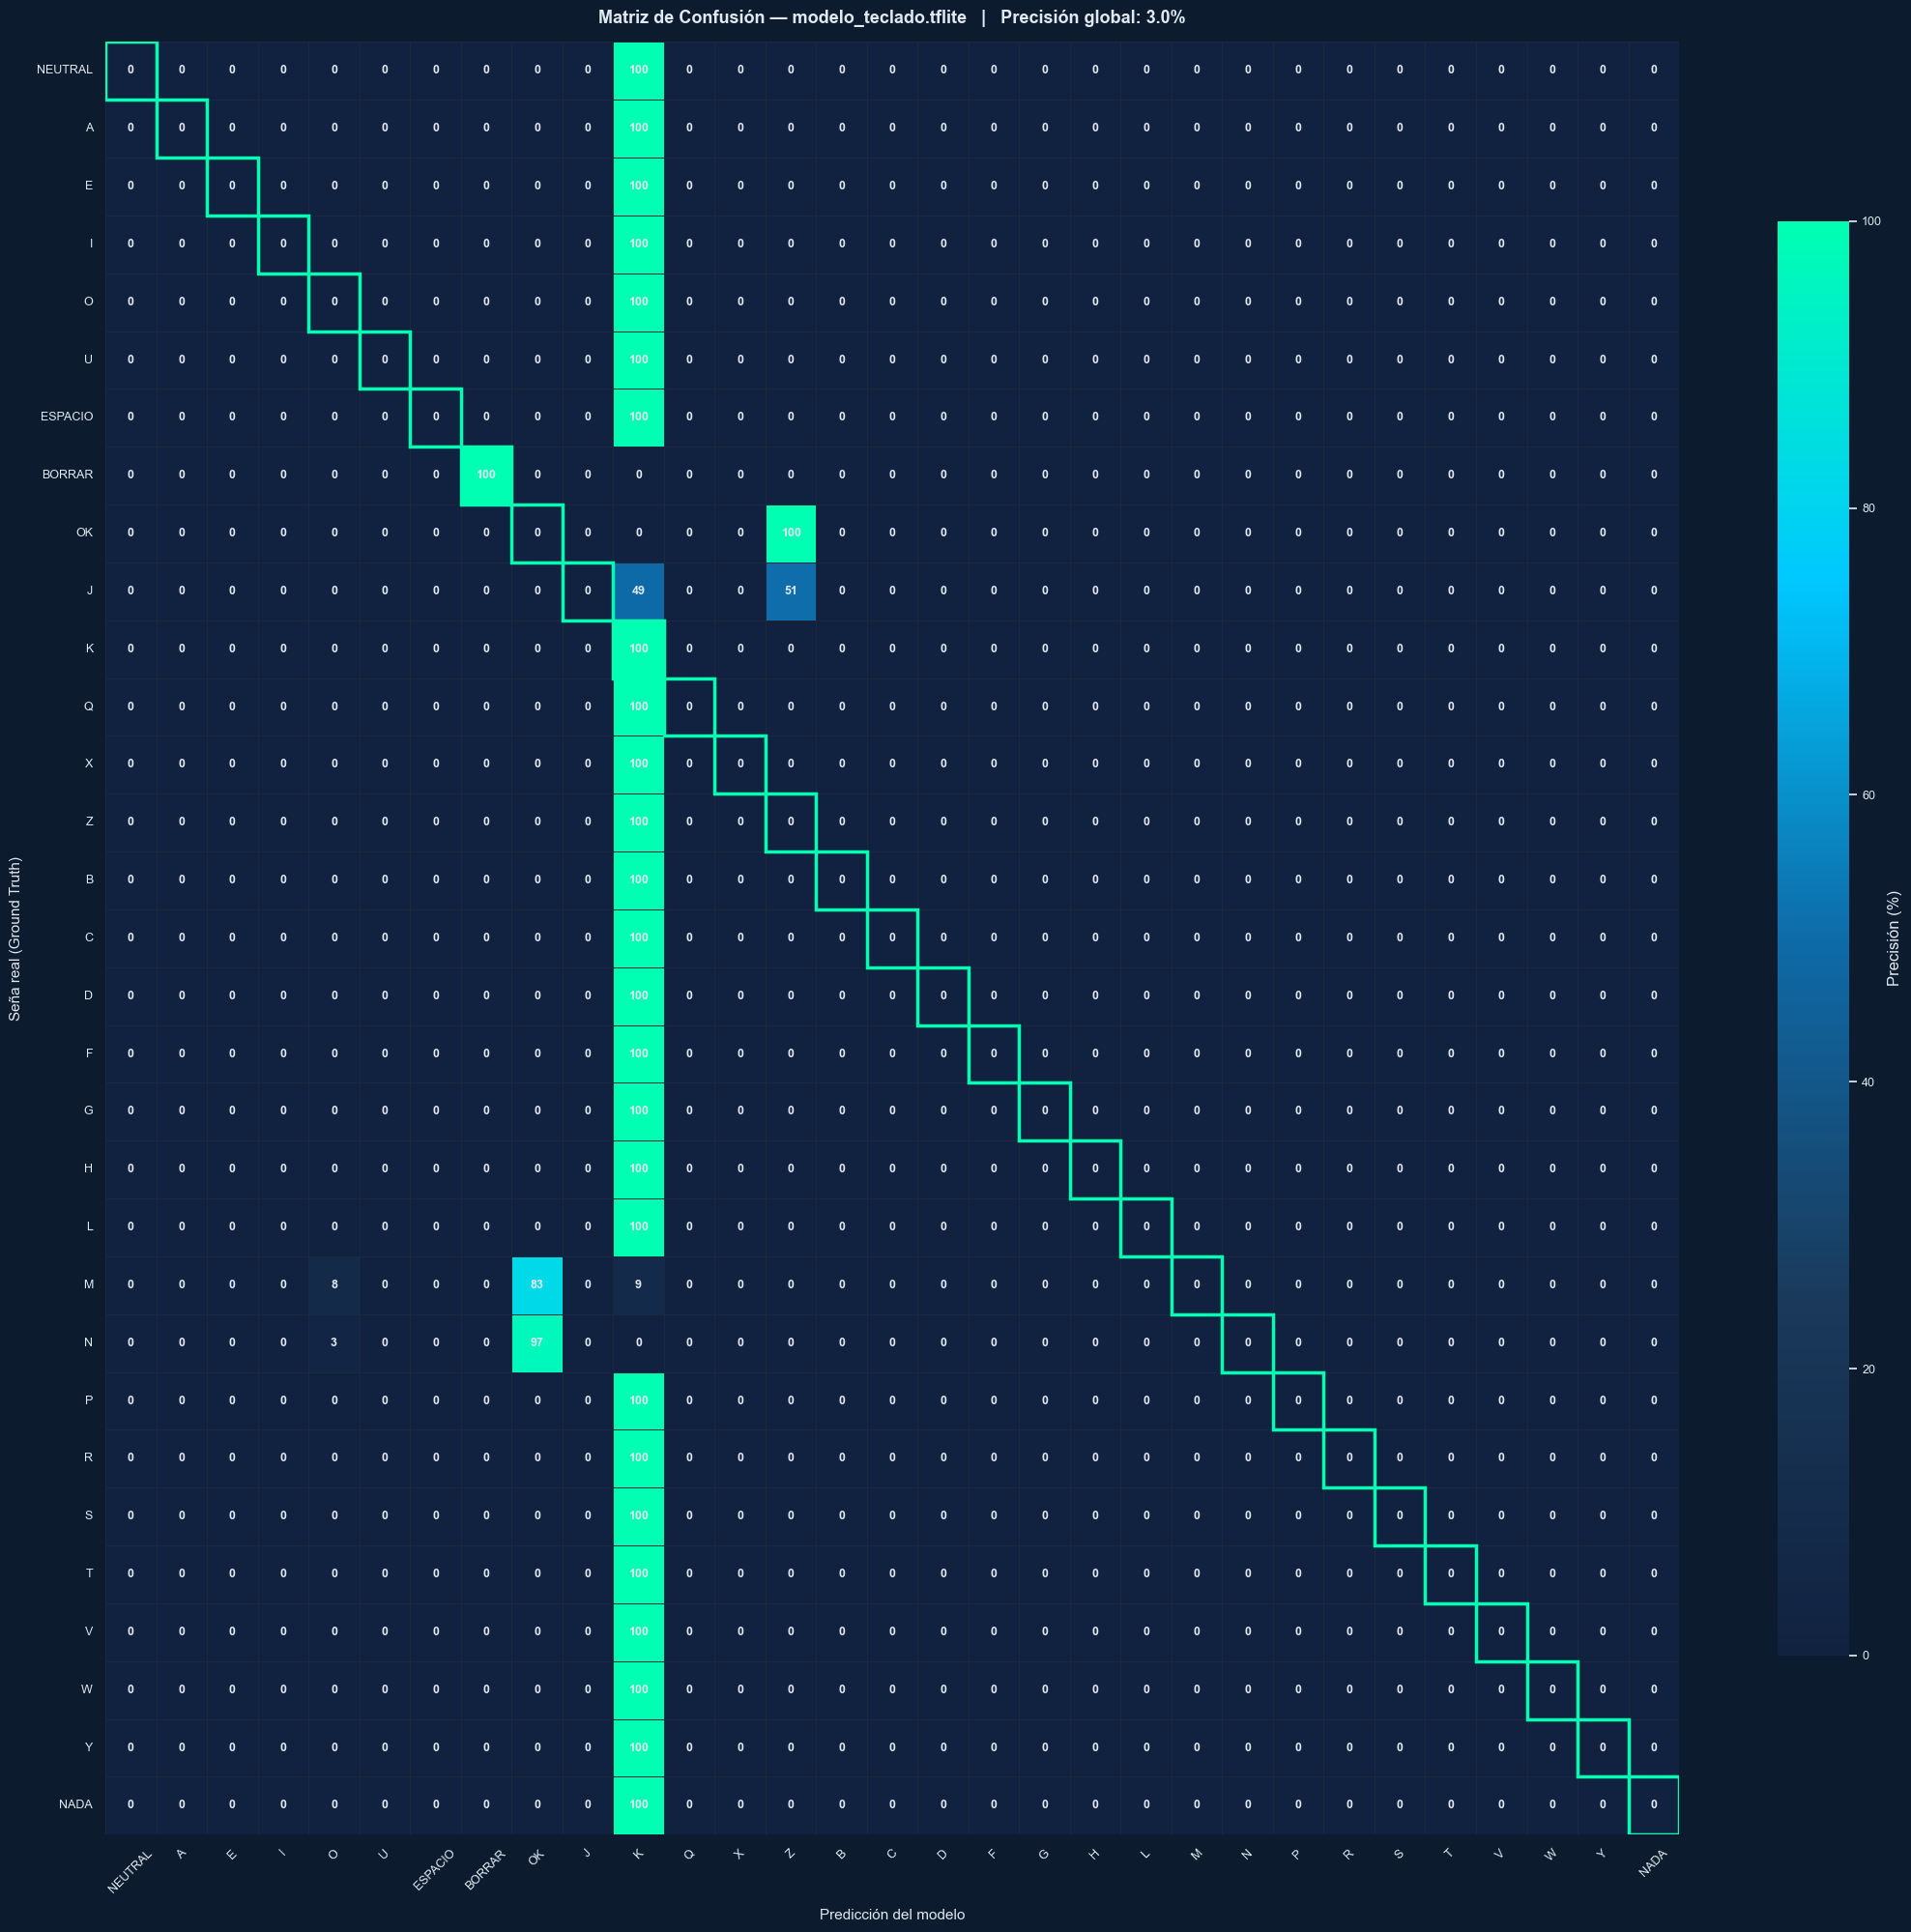

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')


# ── PALETA ───────────────────────────────────────────────────────────
COLOR_FONDO = "#0D1B2E"
COLOR_PANEL = "#112240"
COLOR_TEXTO = "#E0E8F0"
COLOR_GRIS  = "#4A5568"
COLOR_VERDE = "#00FFB2"


# ── CLASES ───────────────────────────────────────────────────────────
nombres_clases = [
    "NEUTRAL", "A", "E", "I", "O", "U",
    "ESPACIO", "BORRAR", "OK",
    "J", "K", "Q", "X", "Z",
    "B", "C", "D", "F", "G",
    "H", "L", "M", "N", "P",
    "R", "S", "T", "V", "W",
    "Y", "NADA"
]


# ── CARGAR MODELO Y DATOS ────────────────────────────────────────────
print("🔄 Cargando modelo y datos...")
interpreter = tf.lite.Interpreter(model_path="modelo_teclado.tflite")
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()


df     = pd.read_csv('datasetLETRAS.csv', on_bad_lines='skip')
X      = df.iloc[:, 1:].values.astype(np.float32)
y_true = df.iloc[:, 0].values.astype(int)


# ── PREDICCIONES ─────────────────────────────────────────────────────
print("🔄 Generando predicciones...")
y_pred = []
for i in range(len(X)):
    inp = np.expand_dims(X[i], axis=0)
    interpreter.set_tensor(input_details[0]['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    y_pred.append(int(np.argmax(out[0])))
y_pred = np.array(y_pred)


# ── MATRIZ ───────────────────────────────────────────────────────────
clases_presentes = sorted(list(set(y_true) | set(y_pred)))
etiquetas = [nombres_clases[i] if i < len(nombres_clases) else str(i)
             for i in clases_presentes]


cm       = confusion_matrix(y_true, y_pred, labels=clases_presentes)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm  = cm.astype(float) / row_sums * 100


accuracy = accuracy_score(y_true, y_pred) * 100
print(f"   Precisión global: {accuracy:.1f}%")


# ── FIGURA ───────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
n = len(clases_presentes)


fig, ax = plt.subplots(figsize=(max(14, n*0.7), max(12, n*0.65)),
                       facecolor=COLOR_FONDO)
ax.set_facecolor(COLOR_PANEL)


cmap = LinearSegmentedColormap.from_list(
    "lsm", [COLOR_PANEL, "#1a3a5c", "#0e6ba8", "#00C8FF", "#00FFB2"], N=256
)


sns.heatmap(
    cm_norm,
    annot=True, fmt='.0f',
    cmap=cmap,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    linewidths=0.4, linecolor="#1a2a3a",
    cbar=True, cbar_kws={"shrink": 0.8, "label": "Precisión (%)"},
    ax=ax, vmin=0, vmax=100,
    annot_kws={"size": 9, "weight": "bold", "color": COLOR_TEXTO}
)


# Resaltar diagonal (aciertos)
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                 fill=False, edgecolor=COLOR_VERDE, linewidth=2.5, zorder=5))


# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(COLOR_TEXTO)
cbar.ax.tick_params(colors=COLOR_TEXTO, labelsize=9)


ax.set_title(
    f'Matriz de Confusión — modelo_teclado.tflite   |   Precisión global: {accuracy:.1f}%',
    color=COLOR_TEXTO, fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Predicción del modelo', color=COLOR_TEXTO, fontsize=11, labelpad=10)
ax.set_ylabel('Seña real (Ground Truth)', color=COLOR_TEXTO, fontsize=11, labelpad=10)
ax.tick_params(axis='x', colors=COLOR_TEXTO, labelsize=9, rotation=45)
ax.tick_params(axis='y', colors=COLOR_TEXTO, labelsize=9, rotation=0)
for sp in ax.spines.values():
    sp.set_edgecolor(COLOR_GRIS)


plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight', facecolor=COLOR_FONDO)
print("✅ Guardada como 'matriz_confusion.png'")
plt.show()
